# 02 – Feature Engineering & Preprocessing
**Project:** SmartBank Customer Churn  
**Objective:** Clean the merged data, engineer domain-driven features, encode categoricals, scale numerics, and produce a model-ready dataset.


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_raw_data
from src.data.preprocess import preprocess
from src.features.build_features import engineer_features, encode_and_scale, save_artefacts

sns.set_theme(style='whitegrid', palette='Set2')
print('Ready ✓')

Ready ✓


## 1. Load & Preprocess

In [2]:
raw = load_raw_data()
print('Raw shape:', raw.shape)
raw.head()

2026-04-29 12:47:58 | INFO     | src.data.load_data | Loading sheet 'Customer_Demographics' …
2026-04-29 12:47:58 | INFO     | src.data.load_data |   → 1000 rows, 5 cols
2026-04-29 12:47:58 | INFO     | src.data.load_data | Loading sheet 'Transaction_History' …
2026-04-29 12:47:59 | INFO     | src.data.load_data |   → 5054 rows, 5 cols
2026-04-29 12:47:59 | INFO     | src.data.load_data | Loading sheet 'Customer_Service' …
2026-04-29 12:47:59 | INFO     | src.data.load_data |   → 1002 rows, 5 cols
2026-04-29 12:47:59 | INFO     | src.data.load_data | Loading sheet 'Online_Activity' …
2026-04-29 12:47:59 | INFO     | src.data.load_data |   → 1000 rows, 4 cols
2026-04-29 12:47:59 | INFO     | src.data.load_data | Loading sheet 'Churn_Status' …
2026-04-29 12:47:59 | INFO     | src.data.load_data |   → 1000 rows, 2 cols
2026-04-29 12:47:59 | INFO     | src.data.load_data | Merging all sources on CustomerID …
2026-04-29 12:47:59 | INFO     | src.data.load_data | Merge complete → 1000 rows, 

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalSpent,AvgTransactionValue,NumTransactions,TopProductCategory,NumServiceInteractions,UnresolvedInteractions,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,416.50,416.50000,1,Electronics,1,0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,1547.42,221.06000,7,Electronics,1,0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,1702.98,283.83000,6,Groceries,1,0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,917.29,183.45800,5,Electronics,2,1,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,2001.49,250.18625,8,Groceries,0,0,2023-10-27,41,Website,0


In [5]:
clean = preprocess(raw, save=True)
print('Clean shape:', clean.shape)
clean.isnull().sum().sum()   # should be 0

2026-04-29 12:50:42 | INFO     | src.data.preprocess | === Preprocessing pipeline start ===
2026-04-29 12:50:42 | INFO     | src.data.preprocess | Duplicates removed: 1000 → 1000 rows
2026-04-29 12:50:42 | INFO     | src.data.preprocess | No missing values detected.
2026-04-29 12:50:42 | INFO     | src.data.preprocess | Final cleaned shape: 1000 rows × 15 cols
2026-04-29 12:50:42 | INFO     | src.data.preprocess | Cleaned data saved → C:\Users\amith\Downloads\customer-churn-project\customer-churn-project\data\processed\churn_processed.csv
2026-04-29 12:50:42 | INFO     | src.data.preprocess | === Preprocessing pipeline end ===
Clean shape: (1000, 15)


np.int64(0)

## 2. Outlier Inspection (Before Capping)

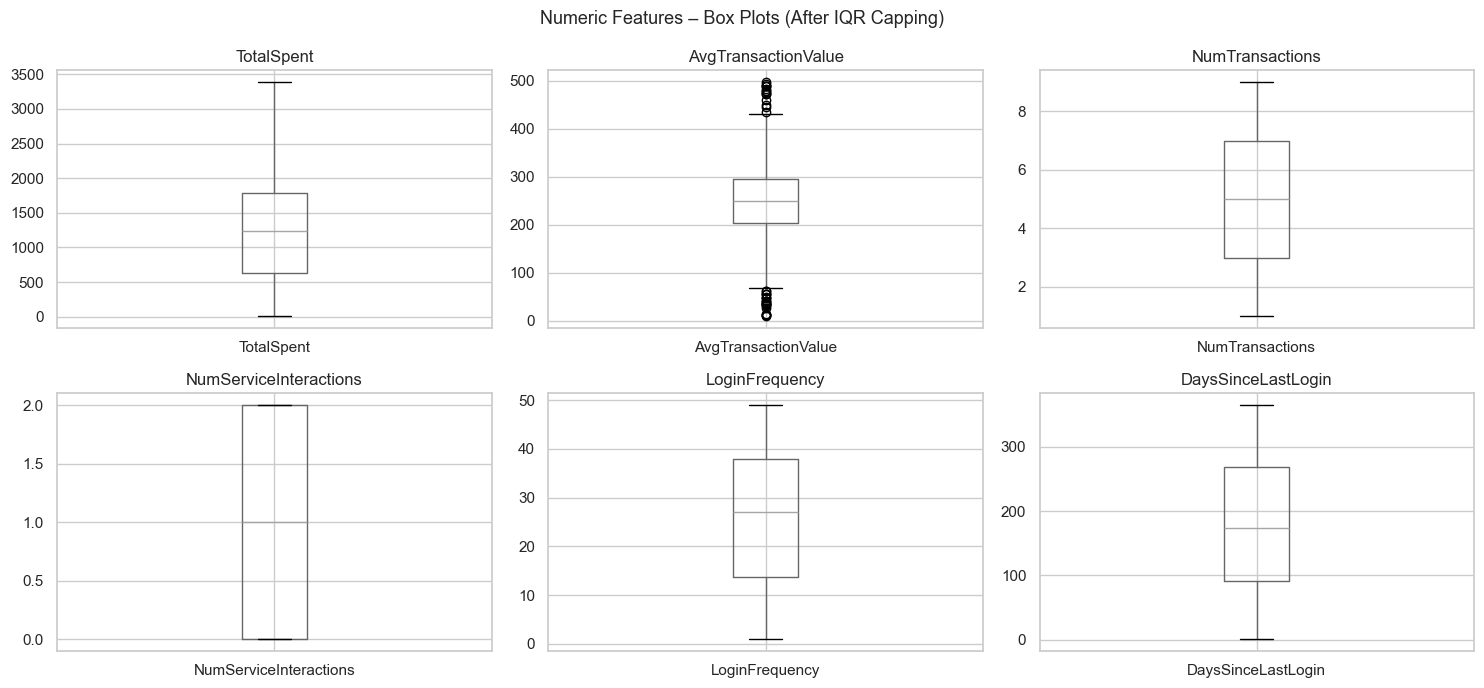

In [6]:
num_cols = ['TotalSpent', 'AvgTransactionValue', 'NumTransactions',
            'NumServiceInteractions', 'LoginFrequency', 'DaysSinceLastLogin']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), num_cols):
    clean.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.suptitle('Numeric Features – Box Plots (After IQR Capping)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Engineer New Features

In [7]:
df_feat = engineer_features(clean)
new_cols = ['SpendPerLogin', 'ServicePressureRatio', 'HighUnresolved', 'AgeGroup']
df_feat[new_cols + ['ChurnStatus']].describe(include='all').T

2026-04-29 12:50:58 | INFO     | src.features.build_features | Engineered 4 new features: SpendPerLogin, ServicePressureRatio, HighUnresolved, AgeGroup


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SpendPerLogin,1000.0,NaN,NaN,NaN,106.811267,220.873365,0.213043,25.688366,48.788415,91.445327,2576.78
ServicePressureRatio,1000.0,NaN,NaN,NaN,0.3155,0.410339,0.0,0.0,0.0,0.5,1.0
HighUnresolved,1000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AgeGroup,1000,3,Senior,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChurnStatus,1000.0,NaN,NaN,NaN,0.204,0.403171,0.0,0.0,0.0,0.0,1.0


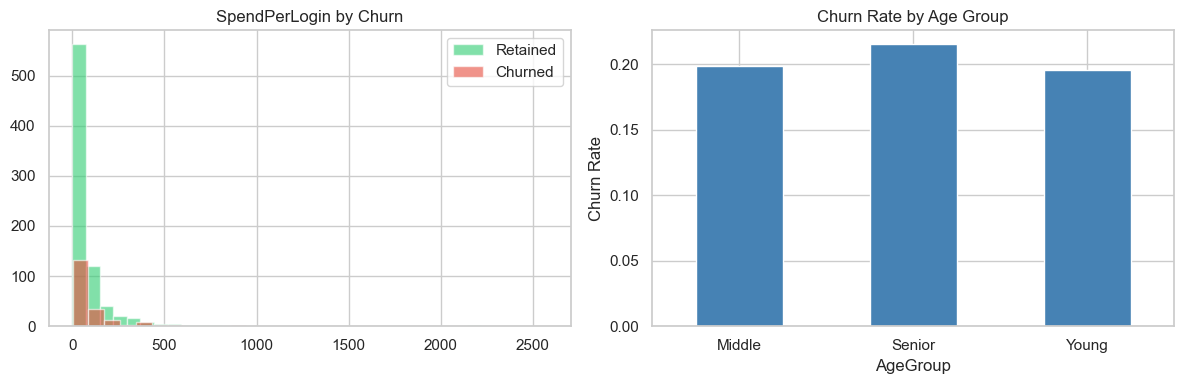

In [8]:
# SpendPerLogin by churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, colour, label in [(0, '#2ecc71', 'Retained'), (1, '#e74c3c', 'Churned')]:
    axes[0].hist(df_feat[df_feat['ChurnStatus'] == val]['SpendPerLogin'],
                 bins=30, alpha=0.6, color=colour, label=label)
axes[0].set_title('SpendPerLogin by Churn')
axes[0].legend()

spr = df_feat.groupby('AgeGroup')['ChurnStatus'].mean()
spr.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Churn Rate by Age Group')
axes[1].set_ylabel('Churn Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 4. Encode & Scale

In [9]:
df_enc, scaler, encoder = encode_and_scale(df_feat, fit=True)
save_artefacts(scaler, encoder)
print('Encoded shape:', df_enc.shape)
df_enc.head()

2026-04-29 12:52:09 | INFO     | src.features.build_features | StandardScaler fitted on 10 numeric columns
2026-04-29 12:52:09 | INFO     | src.features.build_features | OneHotEncoder fitted on 6 categorical columns → 20 OHE features
2026-04-29 12:52:09 | INFO     | src.features.build_features | Final feature matrix: 1000 rows × 33 cols
2026-04-29 12:52:09 | INFO     | src.features.build_features | Scaler → C:\Users\amith\Downloads\customer-churn-project\customer-churn-project\models\scaler.pkl
2026-04-29 12:52:09 | INFO     | src.features.build_features | Encoder → C:\Users\amith\Downloads\customer-churn-project\customer-churn-project\models\encoder.pkl
Encoded shape: (1000, 33)


,CustomerID,ChurnStatus,Age,TotalSpent,AvgTransactionValue,NumTransactions,NumServiceInteractions,UnresolvedInteractions,LoginFrequency,DaysSinceLastLogin,...,TopProductCategory_Clothing,TopProductCategory_Electronics,TopProductCategory_Furniture,TopProductCategory_Groceries,ServiceUsage_Mobile App,ServiceUsage_Online Banking,ServiceUsage_Website,AgeGroup_Middle,AgeGroup_Senior,AgeGroup_Young
0,1,0,1.229628,-1.152196,2.113790,-1.557954,-0.002451,-0.771419,0.575702,-1.021557,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2,1,1.426547,0.379758,-0.349747,0.747849,-0.002451,-0.771419,-1.488513,-1.450763,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,3,0,-1.658518,0.590481,0.441474,0.363548,-0.002451,-0.771419,-1.630872,-1.260005,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,4,0,-1.461599,-0.473822,-0.823723,-0.020752,1.222911,0.839059,-1.702052,-0.477897,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,5,0,-1.461599,0.994845,0.017392,1.132149,-1.227812,-0.771419,1.073961,-1.078785,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


## 5. Feature Correlation with Target

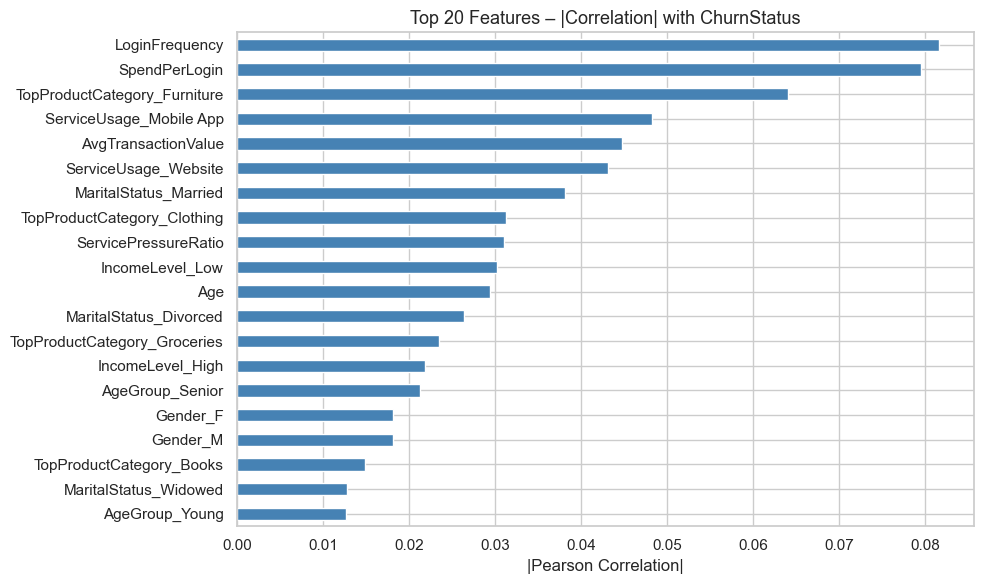

In [10]:
feature_cols = [c for c in df_enc.columns if c not in ['CustomerID', 'ChurnStatus']]
corr_target = df_enc[feature_cols + ['ChurnStatus']].corr()['ChurnStatus'].drop('ChurnStatus')
corr_target = corr_target.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
corr_target.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Features – |Correlation| with ChurnStatus', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()

## 6. Save Processed Dataset

In [11]:
from src.utils.config import PROCESSED_DATA_PATH
df_enc.to_csv(PROCESSED_DATA_PATH, index=False)
print(f'Saved → {PROCESSED_DATA_PATH}')
print(f'Shape: {df_enc.shape}')

Saved → C:\Users\amith\Downloads\customer-churn-project\customer-churn-project\data\processed\churn_processed.csv
Shape: (1000, 33)


## Summary of Feature Engineering Decisions

| Feature | Type | Rationale |
|---|---|---|
| `SpendPerLogin` | Ratio | Captures spend efficiency per session |
| `ServicePressureRatio` | Ratio | Proxy for customer frustration |
| `HighUnresolved` | Binary flag | Threshold effect: >2 unresolved strongly predicts churn |
| `AgeGroup` | Ordinal bucket | Age has non-linear relationship with churn |
| `DaysSinceLastLogin` | Derived numeric | Derived from LastLoginDate; more interpretable |

All numeric features are **StandardScaler** normalised.  
All categorical features are **One-Hot Encoded** (`handle_unknown='ignore'` for inference safety).
